In [14]:
results = pd.DataFrame({
    "Actual G3": y_test.values,
    "Predicted G3": y_pred_rf
})

results.head(10)

,Actual G3,Predicted G3
0,10,8.240
1,12,11.770
2,5,6.725
3,10,9.560
4,9,8.820
5,13,12.850
6,18,18.685
7,6,6.855
8,0,7.005
9,14,13.345


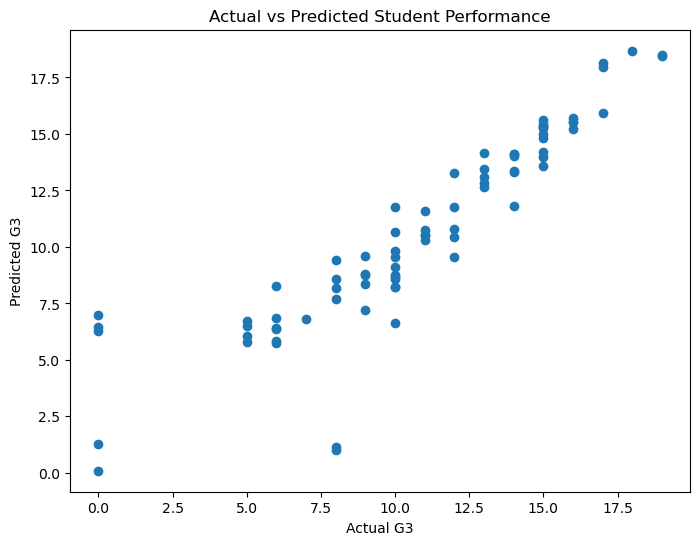

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Student Performance")

plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))

Model Performance
------------------
MAE : 1.17
RMSE: 1.97
R²  : 0.81


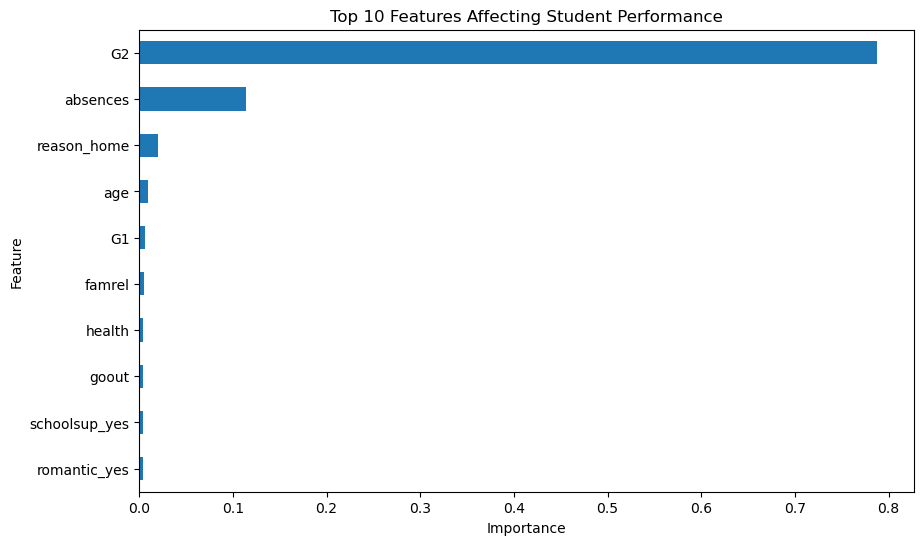

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
)

# Select top 10 features
top_features = importance.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")

plt.title("Top 10 Features Affecting Student Performance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [10]:
import joblib

joblib.dump(model_rf, "model/student_performance_model.pkl")
joblib.dump(X.columns.tolist(), "model/model_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [9]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [8]:
from sklearn.model_selection import train_test_split

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

# Split encoded data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (316, 41)
Testing shape: (79, 41)


In [7]:
X = df.drop("G3", axis=1)
y = df["G3"]

print("X:", X.shape)
print("y:", y.shape)

X: (395, 32)
y: (395,)


In [6]:
import pandas as pd

df = pd.read_csv("dataset/student-mat.csv", sep=";")

print(df.shape)

(395, 33)


In [ ]:
sample = X_test.iloc[[0]]

actual = y_test.iloc[0]
predicted = loaded_model.predict(sample)[0]

print("Actual G3:", actual)
print("Predicted G3:", round(predicted, 2))

Actual G3: 10
Predicted G3: 8.24


In [ ]:
loaded_model = joblib.load("model/student_performance_model.pkl")
model_columns = joblib.load("model/model_columns.pkl")

print("Model loaded successfully!")
print("Number of model features:", len(model_columns))

Model loaded successfully!
Number of model features: 32


In [ ]:
import joblib

joblib.dump(model_rf, "model/student_performance_model.pkl")
joblib.dump(X.columns.tolist(), "model/model_columns.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2 Score": [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.646666,2.378370,0.724134
1,Random Forest,1.173418,1.966632,0.811381


In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 1.1734177215189876
MSE : 3.8676405063291144
RMSE: 1.9666317668361595
R²  : 0.8113810489794643


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.64666561971475
MSE : 5.65664283323122
RMSE: 2.3783697847961363
R²  : 0.7241341236974023


In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 32)
Testing data: (79, 32)


In [ ]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [ ]:
print("G3 values:")
print(df["G3"].value_counts().sort_index())

G3 values:
G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [ ]:
import pandas as pd

df = pd.read_csv("dataset/student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All libraries imported successfully!")


All libraries imported successfully!


In [ ]:
print("Student performance prediction project started!")

Student performance prediction project started!
